# Setup

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.patches import Patch, Rectangle

semantic_thresholds = {
    "Near identical": 0.9,
    "Strong conceptual similarity": 0.7,
    "Partial overlap": 0.5,
    "Low / no semantic relevance": 0.0
}

# Distribution of similarity scores within a single LLM

In [79]:
PROCESS_COLOR   = "#4B5FA0"
NARRATIVE_COLOR = "#B8C4CE"
BOX_COLOR_PROC  = "#C8A020"
BOX_COLOR_NARR  = "#C8A020"
VIOLIN_WIDTH    = 0.38
BOX_HW          = 0.03
GAP             = 0.08

BENCHMARK_SETS_WITHIN = ["full_set", "reduced_set", "noise_20", "noise_40", "noise_60", "noise_80"]
BENCHMARK_LABELS_WITHIN = {
    "full_set":    "Full Set",
    "reduced_set": "Pharmacologically\nActive Set",
    "noise_20":    "Noise 20%",
    "noise_40":    "Noise 40%",
    "noise_60":    "Noise 60%",
    "noise_80":    "Noise 80%",
}

def draw_within_llm_distribution(
    processname_csv: str,
    narrative_csv: str,
    output_path: str = "within_llm_distribution.png",
    title: str = "",
):
    """
    processname_csv: path to evaluation_results_processNames.csv
    narrative_csv:   path to evaluation_results_analyticNarratives.csv
    Draws split half-violins per benchmark set with a gap at center:
      left  — process name (dark blue) with its own gold box plot
      right — analytic narrative (light gray) with its own gold box plot
    """
    df_proc = pd.read_csv(processname_csv)
    df_narr = pd.read_csv(narrative_csv)

    fig, ax = plt.subplots(figsize=(12, 5))

    half_gap = GAP / 2

    for i, bset in enumerate(BENCHMARK_SETS_WITHIN):
        proc_vals = df_proc[df_proc["prediction_type"] == bset]["semantic_similarity"].dropna().values
        narr_vals = df_narr[df_narr["prediction_type"] == bset]["semantic_similarity"].dropna().values

        # Left half-violin + box: process names
        if len(proc_vals) > 1:
            kde = stats.gaussian_kde(proc_vals, bw_method=0.25)
            y   = np.linspace(proc_vals.min(), proc_vals.max(), 300)
            d   = kde(y)
            d   = d / d.max() * VIOLIN_WIDTH
            ax.fill_betweenx(y, i - half_gap - d, i - half_gap, color=PROCESS_COLOR, alpha=0.80)

            q1, med, q3 = np.percentile(proc_vals, [25, 50, 75])
            iqr = q3 - q1
            lo  = max(proc_vals.min(), q1 - 1.5 * iqr)
            hi  = min(proc_vals.max(), q3 + 1.5 * iqr)
            cx  = i - half_gap
            ax.plot([cx, cx], [lo, hi], color=BOX_COLOR_PROC, lw=2.0, zorder=3)
            ax.add_patch(Rectangle((cx - BOX_HW, q1), 2 * BOX_HW, iqr, color=BOX_COLOR_PROC, zorder=4))
            ax.plot(cx, med, "o", color="white", ms=6, zorder=5)

        # Right half-violin + box: analytic narratives
        if len(narr_vals) > 1:
            kde = stats.gaussian_kde(narr_vals, bw_method=0.25)
            y   = np.linspace(narr_vals.min(), narr_vals.max(), 300)
            d   = kde(y)
            d   = d / d.max() * VIOLIN_WIDTH
            ax.fill_betweenx(y, i + half_gap, i + half_gap + d, color=NARRATIVE_COLOR, alpha=0.80)

            q1, med, q3 = np.percentile(narr_vals, [25, 50, 75])
            iqr = q3 - q1
            lo  = max(narr_vals.min(), q1 - 1.5 * iqr)
            hi  = min(narr_vals.max(), q3 + 1.5 * iqr)
            cx  = i + half_gap
            ax.plot([cx, cx], [lo, hi], color=BOX_COLOR_NARR, lw=2.0, zorder=3)
            ax.add_patch(Rectangle((cx - BOX_HW, q1), 2 * BOX_HW, iqr, color=BOX_COLOR_NARR, zorder=4))
            ax.plot(cx, med, "o", color="white", ms=6, zorder=5)

    ax.set_xticks(range(len(BENCHMARK_SETS_WITHIN)))
    ax.set_xticklabels([BENCHMARK_LABELS_WITHIN[b] for b in BENCHMARK_SETS_WITHIN], fontsize=11)
    ax.set_ylabel("Accuracy (Semantic Similarity)", fontsize=12)
    ax.set_xlabel("Benchmark Set", fontsize=12)
    if title:
        ax.set_title(title, fontsize=13)
    ax.set_ylim(0.2, 1.05)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    legend_handles = [
        Patch(facecolor=PROCESS_COLOR,   alpha=0.8, label="Process Name"),
        Patch(facecolor=NARRATIVE_COLOR, alpha=0.8, label="Analytic Narrative"),
    ]
    ax.legend(handles=legend_handles, frameon=False, fontsize=10,
              loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")

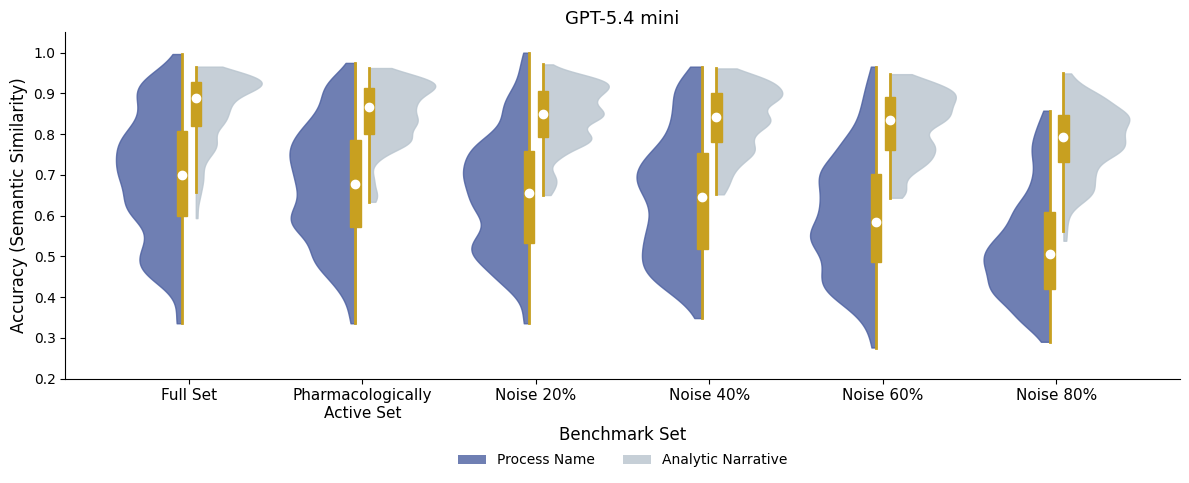

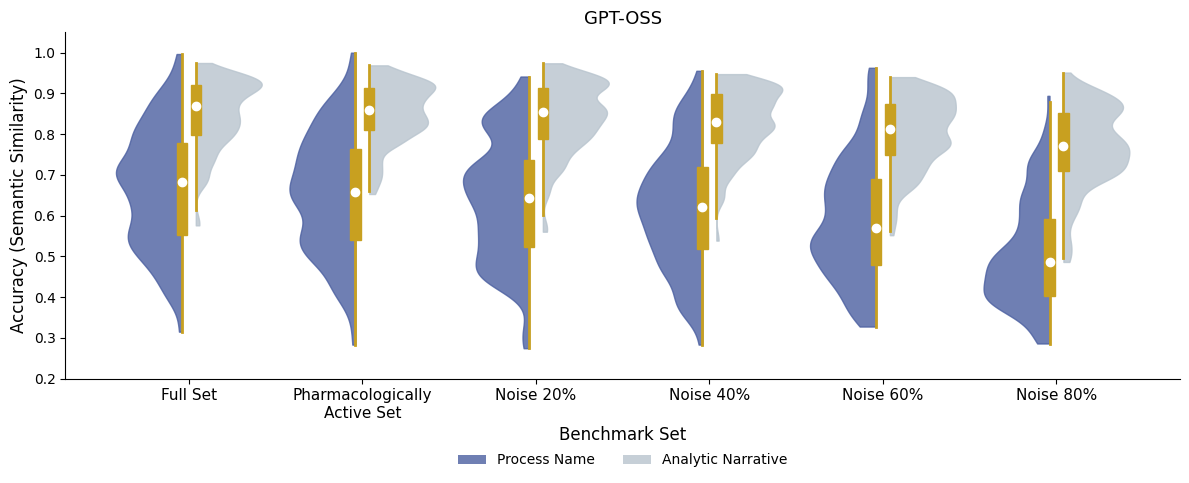

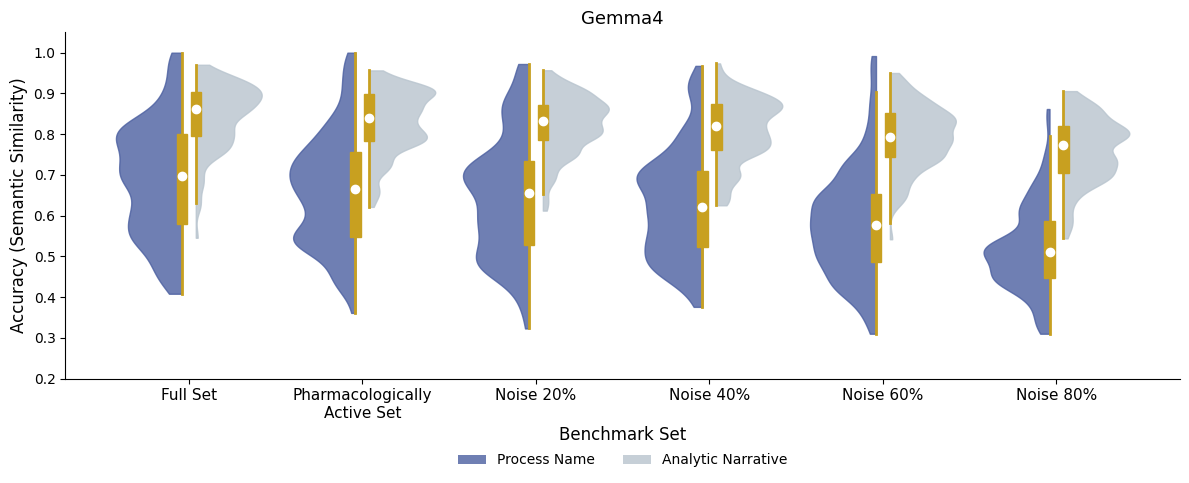

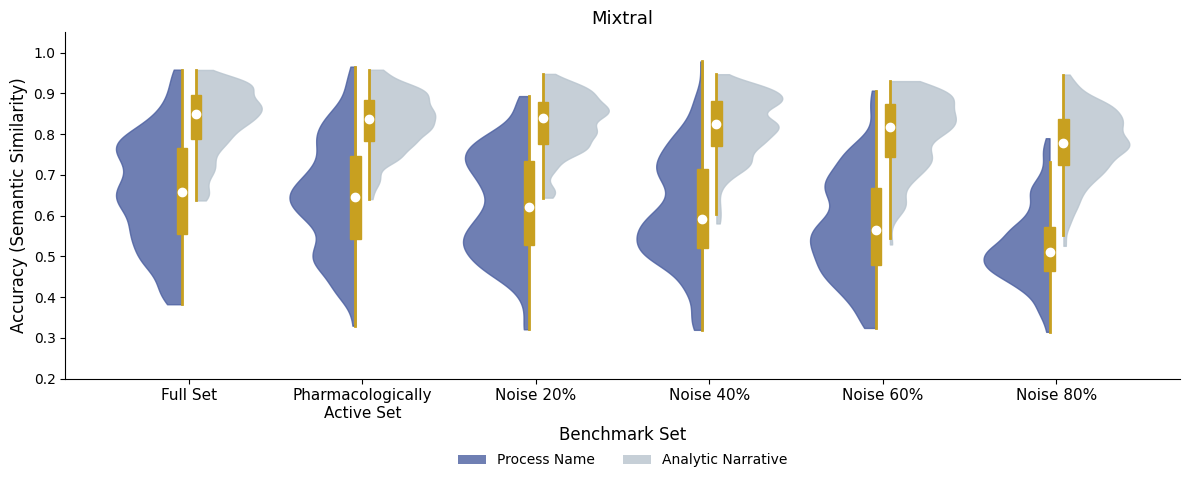

In [80]:
LLM_BASE_PATHS = {
    "GPT-5.4 mini": "Outputs/azure-gpt-5.4-mini",
    "GPT-OSS":       "Outputs/gpt-oss:20b",
    "Gemma4":        "Outputs/gemma4:26b",
    "Mixtral":       "Outputs/mixtral-8x22b",
}

for llm_label, base_path in LLM_BASE_PATHS.items():
    llm_slug = llm_label.lower().replace(" ", "-").replace(":", "")
    draw_within_llm_distribution(
        processname_csv=f"{base_path}/evaluation_results_processNames.csv",
        narrative_csv=f"{base_path}/evaluation_results_analyticNarratives.csv",
        output_path=f"figures/within_llm_{llm_slug}.png",
        title=llm_label,
    )

# Distribution of similarity scores across LLMs

In [83]:
from matplotlib.transforms import blended_transform_factory

BENCHMARK_LABELS = {
    "full_set":    "Full Set",
    "reduced_set": "Pharmacologically Active Set",
    "noise_20":    "Noise 20%",
    "noise_40":    "Noise 40%",
    "noise_60":    "Noise 60%",
    "noise_80":    "Noise 80%",
}

def draw_similarity_distribution(llm_data: dict, output_path: str = "similarity_distribution.png", title: str = ""):
    """
    llm_data: {llm_label: {benchmark_set: np.ndarray of semantic_similarity values}}
    Draws one full violin + box per LLM per benchmark set, grouped by benchmark set on the x-axis.
    """
    LLM_COLORS = {
        "GPT-5.4 mini": "#648FFF",
        "GPT-OSS":       "#785EF0",
        "Gemma4":        "#DC267F",
        "Mixtral":       "#FE6100",
    }
    VIOLIN_WIDTH = 0.16
    SUB_SPACING  = 0.22
    BOX_HW       = 0.02

    benchmark_sets = list(next(iter(llm_data.values())).keys())
    llm_labels     = list(llm_data.keys())
    n_llms         = len(llm_labels)
    offsets        = np.linspace(-(n_llms - 1) / 2, (n_llms - 1) / 2, n_llms) * SUB_SPACING

    def full_violin(ax, values, x_center, color, alpha=0.4, bw=0.25):
        kde = stats.gaussian_kde(values, bw_method=bw)
        y   = np.linspace(values.min(), values.max(), 300)
        d   = kde(y)
        d   = d / d.max() * VIOLIN_WIDTH
        ax.fill_betweenx(y, x_center - d / 2, x_center + d / 2, color=color, alpha=alpha)

    def box_plot(ax, values, x_center, color):
        q1, med, q3 = np.percentile(values, [25, 50, 75])
        iqr = q3 - q1
        lo  = max(values.min(), q1 - 1.5 * iqr)
        hi  = min(values.max(), q3 + 1.5 * iqr)
        ax.plot([x_center, x_center], [lo, hi], color=color, lw=1.4, zorder=3)
        ax.add_patch(Rectangle((x_center - BOX_HW, q1), 2 * BOX_HW, iqr, color=color, zorder=4))
        ax.plot(x_center, med, "o", color="white", ms=4, zorder=5)

    fig, ax = plt.subplots(figsize=(12, 5))

    for i, bset in enumerate(benchmark_sets):
        for j, llm in enumerate(llm_labels):
            x      = i + offsets[j]
            values = llm_data[llm][bset]
            color  = LLM_COLORS[llm]
            full_violin(ax, values, x, color)
            box_plot(ax, values, x, color)

    ax.set_xticks(range(len(benchmark_sets)))
    ax.set_xticklabels([BENCHMARK_LABELS.get(b, b) for b in benchmark_sets], fontsize=11)
    ax.set_ylabel("Accuracy (Semantic Similarity)", fontsize=12)
    ax.set_xlabel("Benchmark Set", fontsize=12)
    if title:
        ax.set_title(title, fontsize=13)
    ax.set_ylim(0.2, 1.05)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Semantic threshold lines and band labels (just right of the axes)
    threshold_items = list(semantic_thresholds.items())
    y_min_vis, y_max_vis = ax.get_ylim()

    bands = []
    for k, (label, lower) in enumerate(threshold_items):
        upper = threshold_items[k - 1][1] if k > 0 else y_max_vis
        bands.append((label, lower, upper))

    trans = blended_transform_factory(ax.transAxes, ax.transData)

    for label, lower, upper in bands:
        if lower >= y_min_vis:
            ax.axhline(lower, color="gray", lw=0.9, ls="--", zorder=1, alpha=0.7)
        mid_y = (max(lower, y_min_vis) + min(upper, y_max_vis)) / 2
        ax.text(
            1.02, mid_y, label,
            transform=trans,
            ha="left", va="center", fontsize=8.5,
            color="dimgray", style="italic",
            bbox=dict(boxstyle="round,pad=0.25", fc="#e8e8e8", ec="none", alpha=0.85),
        )

    # Color legend centered below the x-axis label
    legend_handles = [Patch(facecolor=LLM_COLORS[l], alpha=0.8, label=l) for l in llm_labels]
    ax.legend(handles=legend_handles, frameon=False, fontsize=10,
              loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=len(llm_labels))

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")

## Process Names

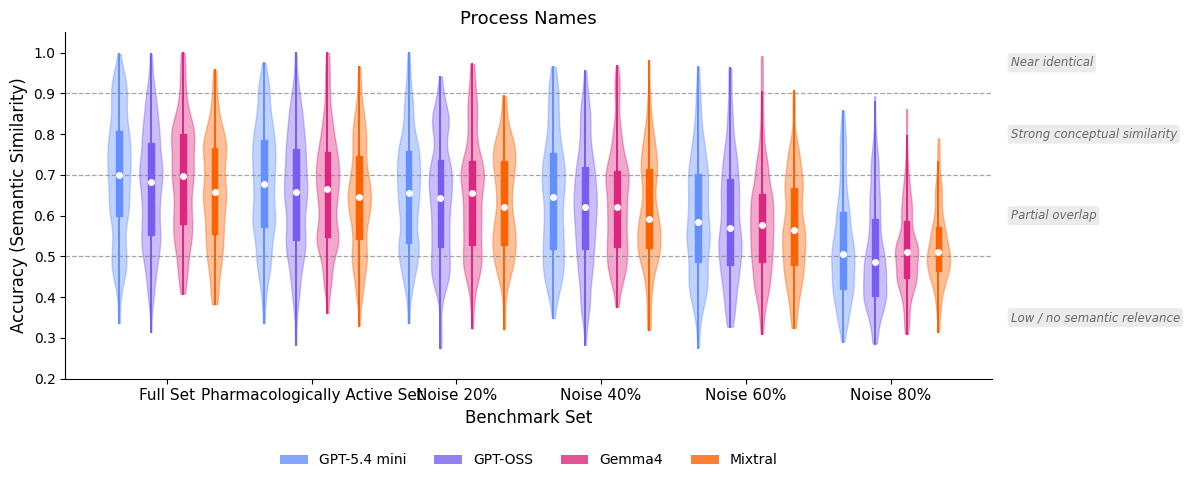

In [84]:
def load_process_name_data(llm_csv_paths: dict, benchmark_sets: list) -> dict:
    """
    llm_csv_paths: {display_label: path_to_evaluation_results_processNames.csv}
    Returns: {display_label: {benchmark_set: np.ndarray of semantic_similarity values}}
    """
    llm_data = {}
    for label, csv_path in llm_csv_paths.items():
        df = pd.read_csv(csv_path)
        llm_data[label] = {
            bset: df[df["prediction_type"] == bset]["semantic_similarity"].dropna().values
            for bset in benchmark_sets
        }
    return llm_data

BENCHMARK_SETS = ["full_set", "reduced_set", "noise_20", "noise_40", "noise_60", "noise_80"]

LLM_CSV_PATHS = {
    "GPT-5.4 mini": "Outputs/azure-gpt-5.4-mini/evaluation_results_processNames.csv",
    "GPT-OSS":       "Outputs/gpt-oss:20b/evaluation_results_processNames.csv",
    "Gemma4":        "Outputs/gemma4:26b/evaluation_results_processNames.csv",
    "Mixtral":       "Outputs/mixtral-8x22b/evaluation_results_processNames.csv",
}

llm_data = load_process_name_data(LLM_CSV_PATHS, BENCHMARK_SETS)
draw_similarity_distribution(llm_data, title="Process Names", output_path="figures/similarity_distribution_processNames.png")

## Analytic Narratives

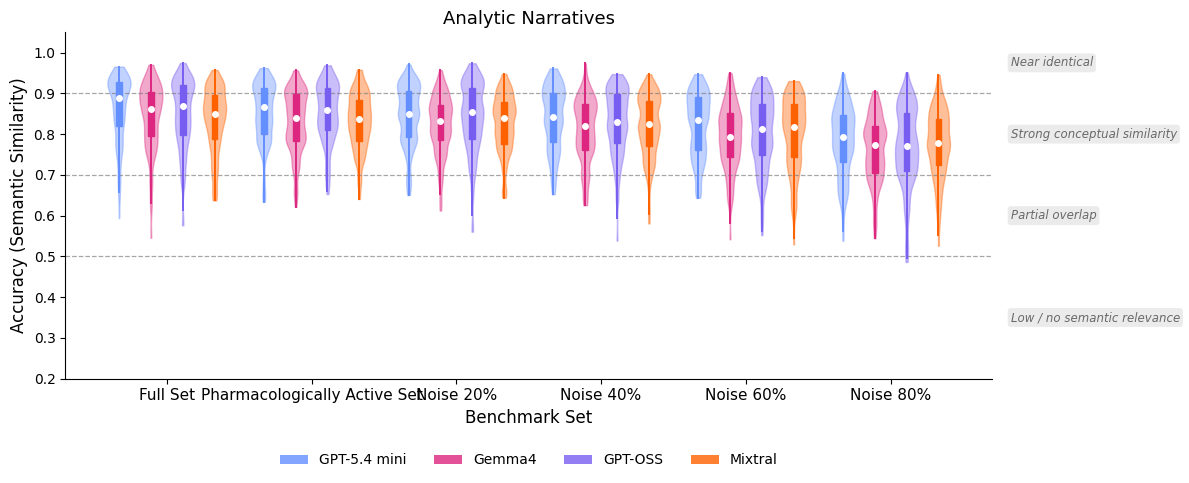

In [85]:
def load_process_name_data(llm_csv_paths: dict, benchmark_sets: list) -> dict:
    """
    llm_csv_paths: {display_label: path_to_evaluation_results_analyticNarratives.csv}
    Returns: {display_label: {benchmark_set: np.ndarray of semantic_similarity values}}
    """
    llm_data = {}
    for label, csv_path in llm_csv_paths.items():
        df = pd.read_csv(csv_path)
        llm_data[label] = {
            bset: df[df["prediction_type"] == bset]["semantic_similarity"].dropna().values
            for bset in benchmark_sets
        }
    return llm_data

BENCHMARK_SETS = ["full_set", "reduced_set", "noise_20", "noise_40", "noise_60", "noise_80"]

LLM_CSV_PATHS = {
    "GPT-5.4 mini": "Outputs/azure-gpt-5.4-mini/evaluation_results_analyticNarratives.csv",
    "Gemma4":        "Outputs/gemma4:26b/evaluation_results_analyticNarratives.csv",
    "GPT-OSS":       "Outputs/gpt-oss:20b/evaluation_results_analyticNarratives.csv",
    "Mixtral":       "Outputs/mixtral-8x22b/evaluation_results_analyticNarratives.csv",
}

llm_data = load_process_name_data(LLM_CSV_PATHS, BENCHMARK_SETS)
draw_similarity_distribution(llm_data, title="Analytic Narratives", output_path="figures/similarity_distribution_analyticNarratives.png")

# Sankey: Semantic Similarity → LLM Judge Score

In [54]:
import plotly.graph_objects as go
from IPython.display import display, HTML

SEM_BINS = [
    "Near identical",
    "Strong conceptual similarity",
    "Partial overlap",
    "Low / no semantic relevance",
]

def bin_semantic(score: float) -> str:
    if score >= 0.9:
        return "Near identical"
    elif score >= 0.7:
        return "Strong conceptual similarity"
    elif score >= 0.5:
        return "Partial overlap"
    else:
        return "Low / no semantic relevance"

def draw_sankey(csv_path: str, noise_level: str, title: str = "", output_filename: str = "sankey"):
    df = pd.read_csv(csv_path).dropna(subset=["semantic_similarity", "llm_judge_score"])
    df = df[df["prediction_type"] == noise_level]
    if df.empty:
        print(f"No data for {noise_level} in {csv_path}")
        return

    df["sem_bin"] = df["semantic_similarity"].apply(bin_semantic)
    df["llm_label"] = df["llm_judge_score"].astype(int).apply(lambda s: f"LLM Score {s}")

    llm_labels = [f"LLM Score {s}" for s in sorted(df["llm_judge_score"].astype(int).unique(), reverse=True)]
    all_labels = SEM_BINS + llm_labels
    idx = {label: i for i, label in enumerate(all_labels)}

    flows = df.groupby(["sem_bin", "llm_label"]).size().reset_index(name="count")
    sources = [idx[r["sem_bin"]]   for _, r in flows.iterrows()]
    targets = [idx[r["llm_label"]] for _, r in flows.iterrows()]
    values  = flows["count"].tolist()

    sem_colors  = ["#2c7bb6", "#74add1", "#fdae61", "#d7191c"]
    llm_colors  = ["#1a9641", "#78c679", "#d9f0a3", "#ffffcc"]
    node_colors = sem_colors + llm_colors[: len(llm_labels)]

    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(
            pad=20, thickness=22,
            line=dict(color="white", width=0.5),
            label=all_labels,
            color=node_colors,
        ),
        link=dict(source=sources, target=targets, value=values),
    ))
    fig.update_layout(
        title_text=title or f"Semantic Similarity → LLM Judge Score ({noise_level})",
        font=dict(size=13),
        margin=dict(l=120, r=120, t=50, b=20),
    )

    fig.write_html(f"{output_filename}.html")
    display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))

In [55]:
SANKEY_LLM_PATHS = {
    "GPT-5.4 mini": "Outputs/azure-gpt-5.4-mini/evaluation_results_processNames.csv",
    "GPT-OSS":       "Outputs/gpt-oss:20b/evaluation_results_processNames.csv",
    "Gemma4":        "Outputs/gemma4:26b/evaluation_results_processNames.csv",
    "Mixtral":       "Outputs/mixtral-8x22b/evaluation_results_processNames.csv",
}

NOISE_LEVELS = ["reduced_set", "noise_20", "noise_40", "noise_60", "noise_80"]

for llm_label, csv_path in SANKEY_LLM_PATHS.items():
    for noise_level in NOISE_LEVELS:
        llm_slug = llm_label.lower().replace(" ", "-").replace(":", "")
        output_filename = f"figures/sankey_{llm_slug}_{noise_level}"
        draw_sankey(
            csv_path=csv_path,
            noise_level=noise_level,
            title=f"{llm_label} · {noise_level}",
            output_filename=output_filename,
        )

# Stacked histogram: Semantic Similarity vs LLM Judge Score

In [114]:
# Stacked from bottom (worst) to top (best)
SEM_BIN_ORDER       = ["Low / no semantic relevance", "Partial overlap", "Strong conceptual similarity", "Near identical"]
SEM_BIN_COLORS_HIST = ["#D73027", "#FDAE61", "#74ADD1", "#2166AC"]
LLM_JUDGE_SCORE_ORDER = [1, 2, 3, 4]
LLM_JUDGE_COLORS_HIST  = [ "#ffffcc", "#d9f0a3", "#78c679", "#1a9641",]

def draw_score_histogram(
    csv_path: str,
    output_path: str = "score_histogram.png",
    title: str = "",
):
    """
    csv_path: path to an evaluation results CSV with semantic_similarity and llm_judge_score columns
    For each benchmark set, draws two stacked bars side by side:
      left bar  — semantic similarity bins  (bottom = no relevance, top = near identical)
      right bar — LLM judge scores          (bottom = score 1, top = highest score)
    """
    df = pd.read_csv(csv_path).dropna(subset=["semantic_similarity", "llm_judge_score"])
    df["sem_bin"]   = df["semantic_similarity"].apply(bin_semantic)
    df["llm_score"] = df["llm_judge_score"].astype(int)

    bar_w = 0.3
    gap   = 0.04
    x     = np.arange(len(BENCHMARK_SETS_WITHIN))

    fig, ax = plt.subplots(figsize=(8, 5))

    # Left stacked bar per benchmark set: semantic similarity bins
    bottoms = np.zeros(len(BENCHMARK_SETS_WITHIN))
    for label, color in zip(SEM_BIN_ORDER, SEM_BIN_COLORS_HIST):
        heights = [
            df[df["prediction_type"] == bset]["sem_bin"].eq(label).sum()
            / max(df[df["prediction_type"] == bset]["sem_bin"].count(), 1)
            for bset in BENCHMARK_SETS_WITHIN
        ]
        ax.bar(x - bar_w / 2 - gap / 2, heights, bar_w, bottom=bottoms, color=color)
        bottoms += np.array(heights)

    # Right stacked bar per benchmark set: LLM judge scores
    bottoms = np.zeros(len(BENCHMARK_SETS_WITHIN))
    for score, color in zip(LLM_JUDGE_SCORE_ORDER, LLM_JUDGE_COLORS_HIST):
        heights = [
            df[df["prediction_type"] == bset]["llm_score"].eq(score).sum()
            / max(df[df["prediction_type"] == bset]["llm_score"].count(), 1)
            for bset in BENCHMARK_SETS_WITHIN
        ]
        ax.bar(x + bar_w / 2 + gap / 2, heights, bar_w, bottom=bottoms, color=color)
        bottoms += np.array(heights)

    ax.set_xticks(x)
    ax.set_xticklabels([BENCHMARK_LABELS_WITHIN[b] for b in BENCHMARK_SETS_WITHIN], fontsize=10)
    ax.set_ylabel("Proportion", fontsize=12)
    ax.set_xlabel("Benchmark Set", fontsize=11)
    ax.set_ylim(0, 1.05)
    if title:
        ax.set_title(title, fontsize=13)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Two-row legend: row 1 = semantic similarity, row 2 = LLM judge scores
    sem_title = Patch(facecolor="none", edgecolor="none", label="Semantic Similarity:")
    sem_handles = [Patch(facecolor=c, label=l) for l, c in zip(SEM_BIN_ORDER, SEM_BIN_COLORS_HIST)]
    sem_handles.reverse()  # Reverse order for legend to match stacked bar order
    llm_title = Patch(facecolor="none", edgecolor="none", label="LLM Judge Score:")
    llm_handles = [Patch(facecolor=c, label=f"Score {s}") for s, c in zip(LLM_JUDGE_SCORE_ORDER, LLM_JUDGE_COLORS_HIST)]
    llm_handles.reverse()  # Reverse order for legend to match stacked bar order

    leg1 = ax.legend(handles=[sem_title] + sem_handles, frameon=False, fontsize=9, 
                     loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=len(sem_handles) + 1)
    ax.add_artist(leg1)
    ax.legend(handles=[llm_title] + llm_handles, frameon=False, fontsize=9, 
              loc="upper center", bbox_to_anchor=(0.5, -0.23), ncol=len(llm_handles) + 1)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")

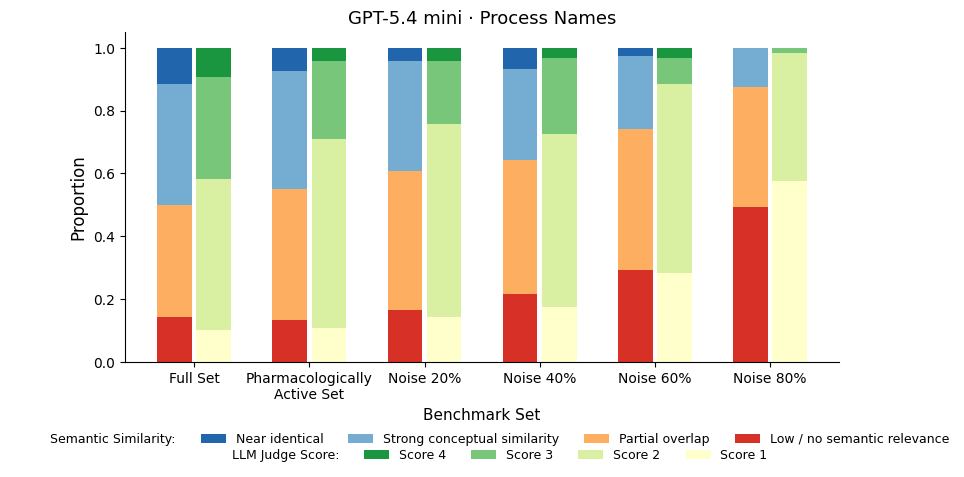

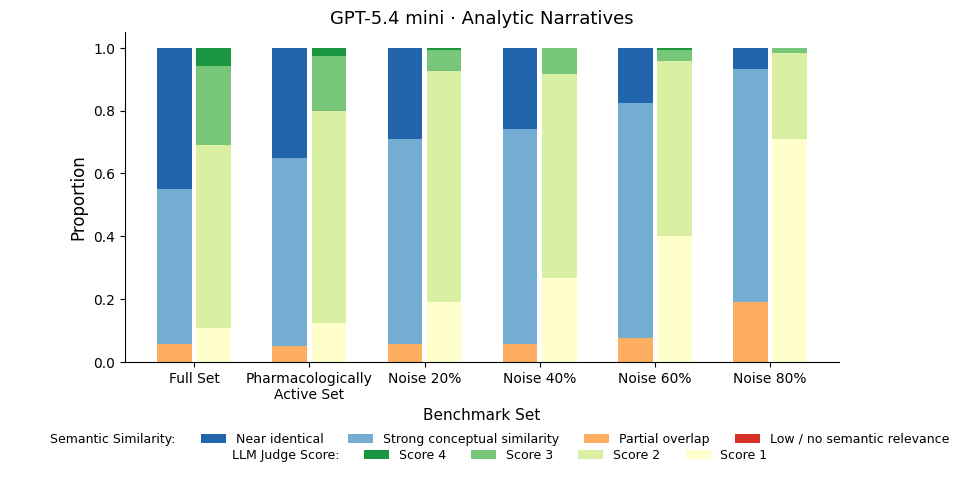

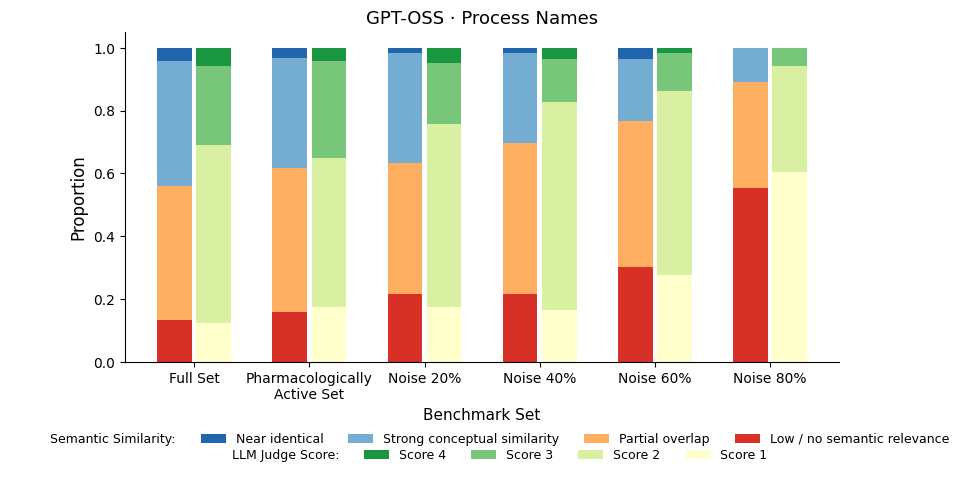

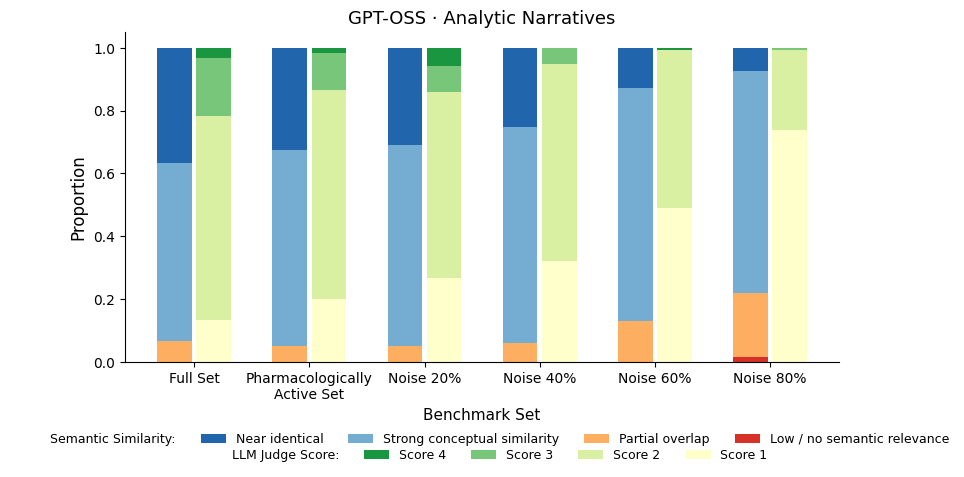

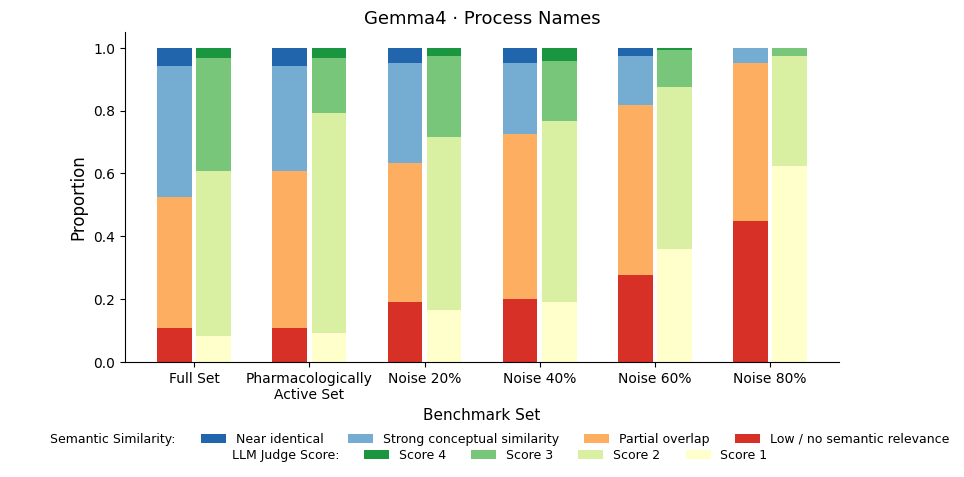

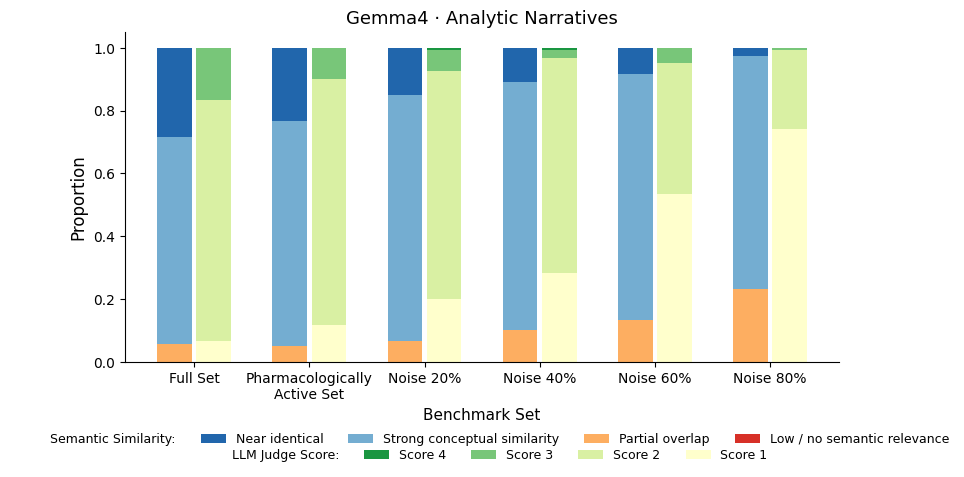

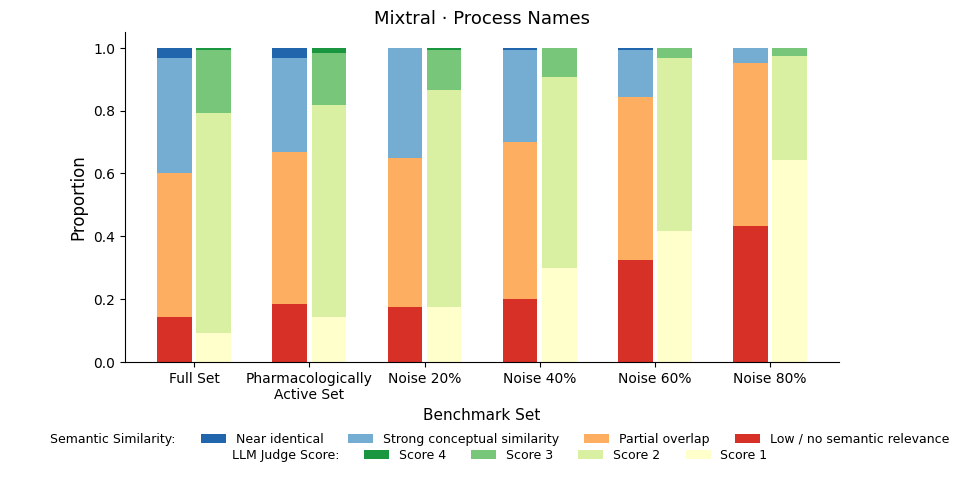

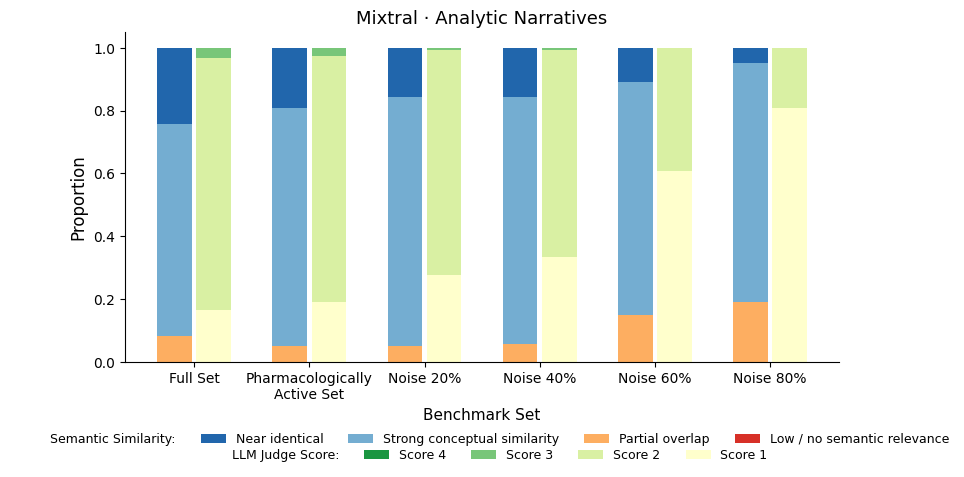

In [115]:
for llm_label, base_path in LLM_BASE_PATHS.items():
    llm_slug = llm_label.lower().replace(" ", "-").replace(":", "")
    for task, suffix in [("Process Names", "processNames"), ("Analytic Narratives", "analyticNarratives")]:
        draw_score_histogram(
            csv_path=f"{base_path}/evaluation_results_{suffix}.csv",
            output_path=f"figures/score_histogram_{llm_slug}_{suffix}.png",
            title=f"{llm_label} · {task}",
        )

# Heatmap: Rank-Based Correlation Between Semantic Similarity and LLM Judge Score

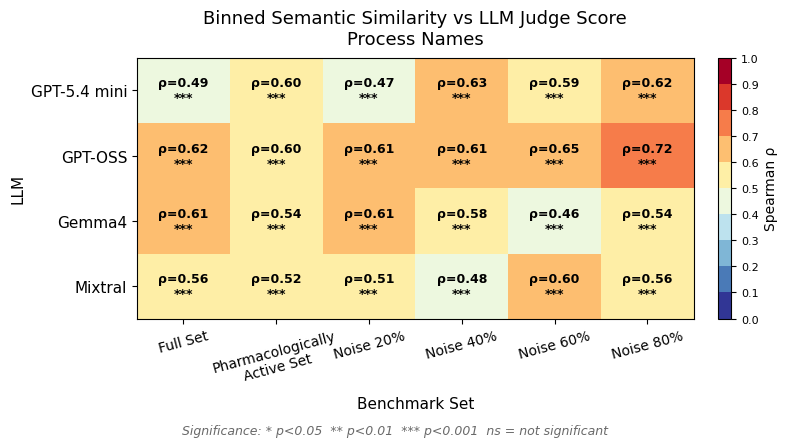

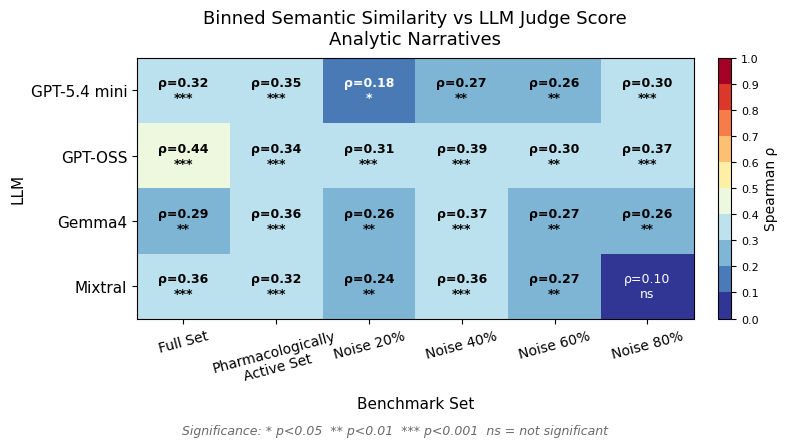

In [127]:
from scipy.stats import spearmanr
import matplotlib.colors as mcolors

HEATMAP_LLM_ORDER = ["GPT-5.4 mini", "GPT-OSS", "Gemma4", "Mixtral"]
HEATMAP_BENCHMARK_SETS = ["full_set", "reduced_set", "noise_20", "noise_40", "noise_60", "noise_80"]
HEATMAP_BENCHMARK_LABELS = [
    "Full Set",
    "Pharmacologically\nActive Set",
    "Noise 20%",
    "Noise 40%",
    "Noise 60%",
    "Noise 80%",
]

HEATMAP_CSV_PATHS = {
    "processNames": {
        "GPT-5.4 mini": "Outputs/azure-gpt-5.4-mini/evaluation_results_processNames.csv",
        "GPT-OSS":       "Outputs/gpt-oss:20b/evaluation_results_processNames.csv",
        "Gemma4":        "Outputs/gemma4:26b/evaluation_results_processNames.csv",
        "Mixtral":       "Outputs/mixtral-8x22b/evaluation_results_processNames.csv",
    },
    "analyticNarratives": {
        "GPT-5.4 mini": "Outputs/azure-gpt-5.4-mini/evaluation_results_analyticNarratives.csv",
        "GPT-OSS":       "Outputs/gpt-oss:20b/evaluation_results_analyticNarratives.csv",
        "Gemma4":        "Outputs/gemma4:26b/evaluation_results_analyticNarratives.csv",
        "Mixtral":       "Outputs/mixtral-8x22b/evaluation_results_analyticNarratives.csv",
    },
}

# Ordinal encoding for semantic similarity bins (matches LLM judge score scale 1–4)
SEM_BIN_CODES = {
    "Low / no semantic relevance":    1,
    "Partial overlap":                2,
    "Strong conceptual similarity":   3,
    "Near identical":                 4,
}

RHO_BOUNDARIES = np.arange(0, 1.1, 0.1)


def _sig_stars(pval: float) -> str:
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    return "ns"


def _compute_spearman_matrix(csv_paths: dict, llm_order: list, benchmark_sets: list):
    """
    Return rho and p-value matrices of shape (n_llms, n_benchmarks).
    Semantic similarity is binned into ordinal codes (1–4) before correlation.
    """
    n_llm = len(llm_order)
    n_bset = len(benchmark_sets)
    rho_mat = np.full((n_llm, n_bset), np.nan)
    pval_mat = np.ones((n_llm, n_bset))

    for i, llm in enumerate(llm_order):
        df = pd.read_csv(csv_paths[llm]).dropna(subset=["semantic_similarity", "llm_judge_score"])
        df["sem_bin_code"] = df["semantic_similarity"].apply(bin_semantic).map(SEM_BIN_CODES)
        for j, bset in enumerate(benchmark_sets):
            subset = df[df["prediction_type"] == bset].dropna(subset=["sem_bin_code"])
            if len(subset) >= 5:
                rho, pval = spearmanr(subset["sem_bin_code"], subset["llm_judge_score"])
                rho_mat[i, j] = rho
                pval_mat[i, j] = pval

    return rho_mat, pval_mat


def draw_correlation_heatmap(
    csv_paths: dict,
    llm_order: list,
    benchmark_sets: list,
    benchmark_labels: list,
    title: str = "",
    output_path: str = "figures/correlation_heatmap.png",
):
    """
    Draw a single Spearman ρ heatmap for one task type.
    Rows = LLMs, columns = benchmark sets.
    Cell color encodes ρ in 0.1-increment bins over [0, 1] using a warm-to-cold
    colormap (red = low correlation, blue = high correlation).
    Annotation shows ρ value and significance stars.
    """
    rho_mat, pval_mat = _compute_spearman_matrix(csv_paths, llm_order, benchmark_sets)

    cmap = plt.cm.RdYlBu_r  # warm (red) at low ρ → cold (blue) at high ρ
    norm = mcolors.BoundaryNorm(boundaries=RHO_BOUNDARIES, ncolors=cmap.N)

    fig, ax = plt.subplots(figsize=(8, 4))

    im = ax.imshow(rho_mat, aspect="auto", cmap=cmap, norm=norm)

    ax.set_xticks(range(len(benchmark_sets)))
    
    ax.set_xticklabels(benchmark_labels, fontsize=10)
    ax.set_yticks(range(len(llm_order)))
    ax.set_yticklabels(llm_order, fontsize=11)
    ax.set_xlabel("Benchmark Set", fontsize=11)
    ax.set_ylabel("LLM", fontsize=11)
    if title:
        ax.set_title(title, fontsize=13, pad=10)

    for i in range(len(llm_order)):
        for j in range(len(benchmark_sets)):
            rho = rho_mat[i, j]
            pval = pval_mat[i, j]
            if np.isnan(rho):
                ax.text(j, i, "n/a", ha="center", va="center", fontsize=9, color="gray")
                continue
            stars = _sig_stars(pval)
            text_color = "white" if rho < 0.2 or rho > 0.75 else "black"
            ax.text(
                j, i,
                f"ρ={rho:.2f}\n{stars}",
                ha="center", va="center",
                fontsize=9, color=text_color,
                fontweight="bold" if stars != "ns" else "normal",
            )

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=RHO_BOUNDARIES)
    cbar.set_label("Spearman ρ", fontsize=10)
    cbar.ax.set_yticklabels([f"{v:.1f}" for v in RHO_BOUNDARIES], fontsize=8)

    sig_note = "Significance: * p<0.05  ** p<0.01  *** p<0.001  ns = not significant"
    fig.text(0.5, -0.1, sig_note, ha="center", fontsize=9, color="dimgray", style="italic")

    plt.tight_layout()
    plt.xticks(rotation=15)
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


for task, task_title in [("processNames", "Process Names"), ("analyticNarratives", "Analytic Narratives")]:
    draw_correlation_heatmap(
        csv_paths=HEATMAP_CSV_PATHS[task],
        llm_order=HEATMAP_LLM_ORDER,
        benchmark_sets=HEATMAP_BENCHMARK_SETS,
        benchmark_labels=HEATMAP_BENCHMARK_LABELS,
        title=f"Binned Semantic Similarity vs LLM Judge Score\n{task_title}",
        output_path=f"figures/correlation_heatmap_{task}.png",
    )